# Code for Theorems 1 and 2

These Theorems are proven explicitly for the Rayleigh fading connection function.

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.special import gamma, zeta
import scienceplots

In [62]:
plt.style.use(['science', 'ieee', 'no-latex'])

In [63]:
def p(r, r0=0.1, eta=2):
    return np.exp(-(r/r0)**eta)


def h2(p):
    if p < 1e-10 or p > 1-1e-10:
        return 0
    return -p*np.log(p)-(1-p)*np.log(1-p)

In [ ]:
def f_line(r):
    if r <= 1:
        return 2 - 2*r
    return 0


def f_rectangle(r, a=1):
    if 0 <= r <= 1/a:
        return 2*r*( np.pi - 2*a*r - 2*r/a + r**2 )
    elif 1/a < r <= a:
        return 2*r*( 2*np.arcsin(1/(a*r)) - 1/(a**2) - 2*(a*r - np.sqrt( a**2*r**2 - 1) ) )
    elif a < r <= np.sqrt(a**2 + 1/a**2):
        return 2*r*( 2*np.arcsin(1/(a*r**2) * (a - np.sqrt((a**2*r**2 - 1) * (r**2 - 1))))
                    + 2*np.sqrt(a**2*r**2 - 1) + 2/a*np.sqrt(r**2 - 1) - a**2 - 1/a*(1+a**2*r**2))
    return 0

def f_cube(r):
    if r <= 1:
        return -r*r*((r-8)*r*r+np.pi*(6*r-4))
    elif r <= np.sqrt(2):
        return 2*r*((r*r-8*np.sqrt(r*r-1)+3)*r*r-4*np.sqrt(r*r-1)+12*r*r*np.arccos(1.0/r)+np.pi*(3-4*r)-0.5)
    elif (r <= np.sqrt(3)):
        return r*((1+r*r)*(6*np.pi+8*np.sqrt(r*r-2)-5-r*r)-16*r*np.arcsin(1.0/np.sqrt(2-2/(r*r)))+16*r*np.arctan(r*np.sqrt(r*r-2))-24*(r*r+1)*np.arctan(np.sqrt(r*r-2)));
    return 0

## Theorem 1 Statement

In [104]:
def H_bar_numerical(r0=0.1, eta=2, d=2):
    if d==1:
        f = f_line
    elif d==2:
        f = lambda r: f_rectangle(r, 1)
    elif d==3:
        f = f_cube
    return quad(lambda r: f(r)*h2(p(r,r0,eta)), 0, np.inf)[0]


def H_bar_extra(r0=0.1, eta=2, d=2):
    a1 = [-2, -4, -6*np.pi][d-1]
    return a1*r0**(d+1)/eta * gamma((d+1)/eta) * ((d+1)/eta + zeta((d+1)/eta + 1) - np.sum([k**(-(d+1)/eta)/(k-1) for k in range(2,100000)]))

# Theorem 1 for Rayleigh fading
def H_bar_paper(r0=0.1, eta=2, d=2):
    s_d_minus_1 = 2*np.pi**(d/2) /gamma(d/2)
    return s_d_minus_1 * r0**d / eta * gamma(d/eta) * (d/eta + zeta(d/eta+1) - np.sum([k**(-d/eta)/(k-1) for k in range(2,100000)]))

In [105]:
for r0 in [0.001, 0.05, 0.1, 0.25]:
    hbn = H_bar_numerical(r0)
    hbp = H_bar_paper(r0)
    print(f"r0 = {r0}: H_bar_numerical = {hbn}, H_bar_paper = {hbp}, Difference = {abs(hbn - hbp)}")

r0 = 0.001: H_bar_numerical = 5.159669190406932e-06, H_bar_paper = 5.167744196290668e-06, Difference = 8.07500588373641e-09
r0 = 0.05: H_bar_numerical = 0.01193127315345155, H_bar_paper = 0.012919360490726672, Difference = 0.000988087337275123
r0 = 0.1: H_bar_numerical = 0.04391540695463374, H_bar_paper = 0.05167744196290669, Difference = 0.007762035008272952
r0 = 0.25: H_bar_numerical = 0.2083777998425691, H_bar_paper = 0.3229840122681668, Difference = 0.11460621242559771


## Figure 1 Plotting

C:\Users\dh23880\AppData\Local\Temp\ipykernel_23644\4233067520.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return np.exp(-(r/r0)**eta)


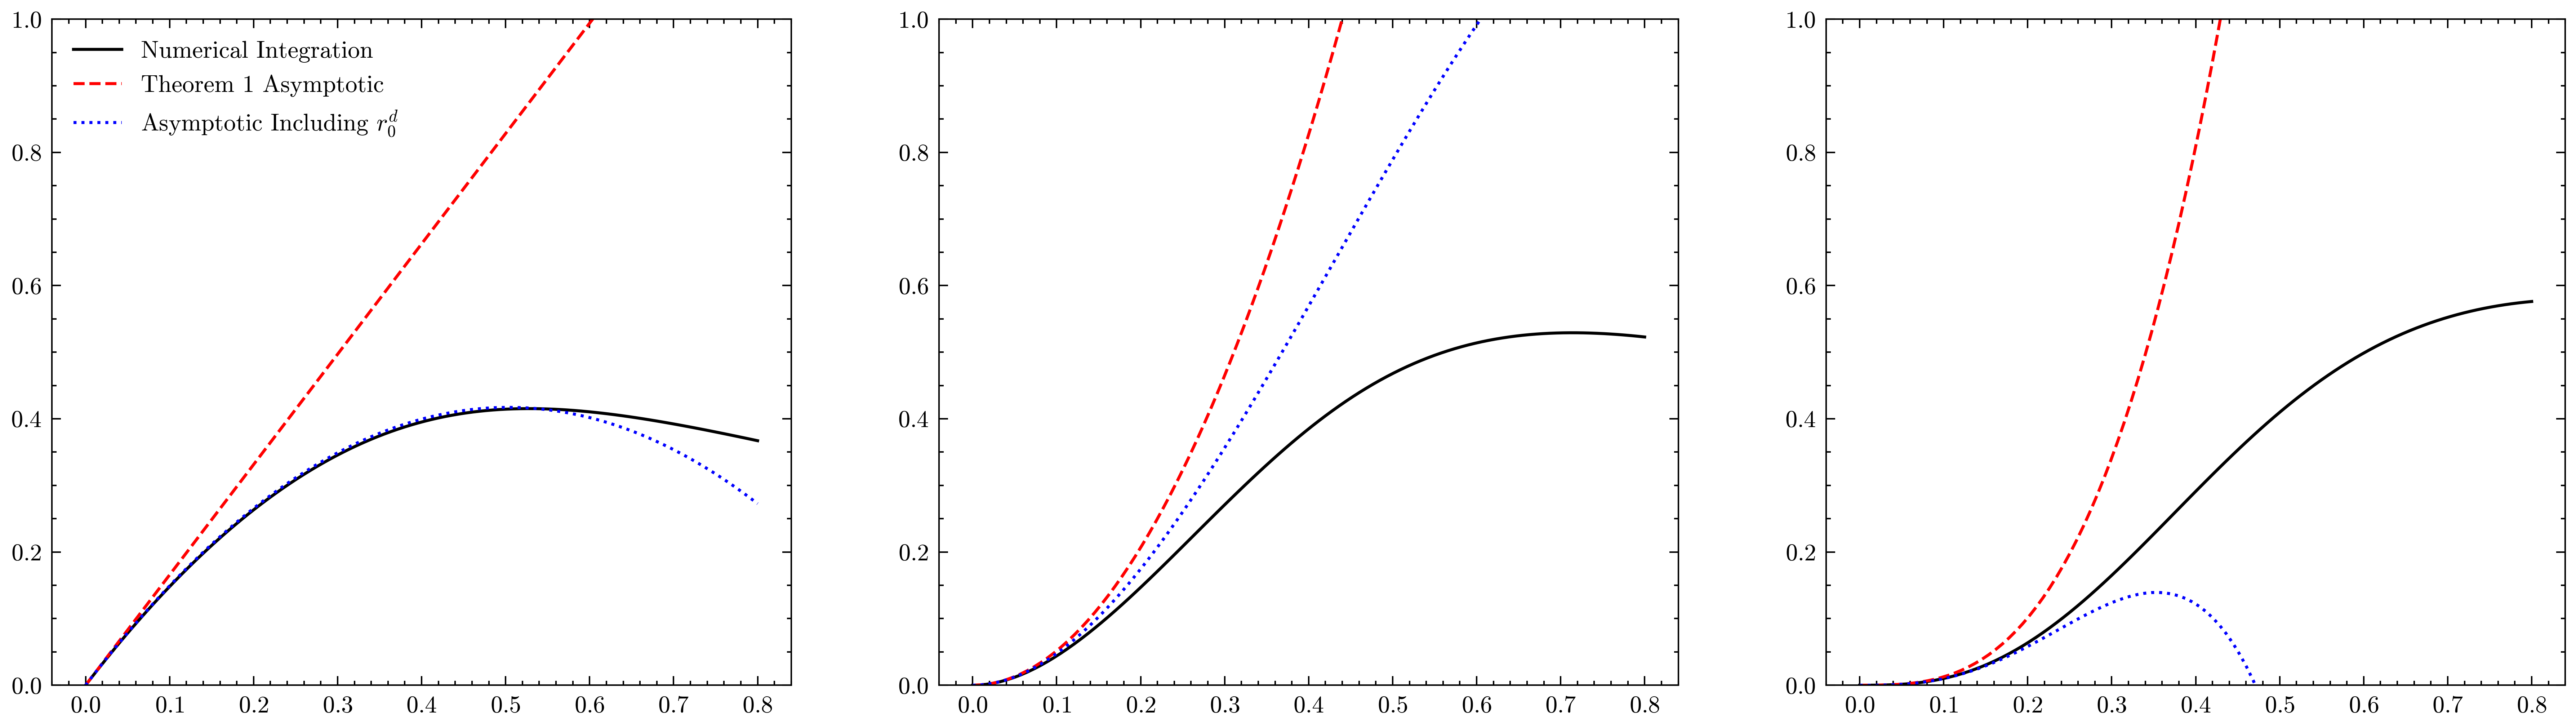

In [106]:
eta = 2
fig, ax = plt.subplots(1,3, figsize=(15,4))
r0_range = np.linspace(0,0.8,100)
for d in [1,2,3]:
    numerical = np.array([H_bar_numerical(r0, eta, d) for r0 in r0_range])
    paper = np.array([H_bar_paper(r0, eta, d) for r0 in r0_range])
    paper_extra = paper+np.array([H_bar_extra(r0, eta, d) for r0 in r0_range])
    ax[d-1].plot(r0_range, numerical, label="Numerical Integration")
    ax[d-1].plot(r0_range, paper, label="Theorem 1 Asymptotic")
    ax[d-1].plot(r0_range, paper_extra, label=r"Asymptotic Including $r_0^d$")
    ax[d-1].set_ylim(0,1)
ax[0].legend()
plt.show()

## Theorem 2 Statement

In [140]:
def ERmoment(d, eta, L=10000):
    tot = 0
    for _ in range(L):
        xs = np.random.uniform(0,1,(2,d))
        tot += np.linalg.norm(xs[0]-xs[1])**eta
    return tot/L


def ERmoment2(d, eta, L=10000):
    tot = 0
    for _ in range(L):
        xs = np.random.uniform(0,1,(2,d))
        tot += np.linalg.norm(xs[0]-xs[1])**(2*eta)
    return tot/L


def ERlogRmoment(d, eta, L=10000):
    tot = 0
    for _ in range(L):
        xs = np.random.uniform(0,1,(2,d))
        R = np.linalg.norm(xs[0]-xs[1])
        tot += np.log(R)*R**eta
    return tot/L

def ERlogRmoment2(d, eta, L=10000):
    tot = 0
    for _ in range(L):
        xs = np.random.uniform(0,1,(2,d))
        R = np.linalg.norm(xs[0]-xs[1])
        tot += np.log(R)*R**(2*eta)
    return tot/L


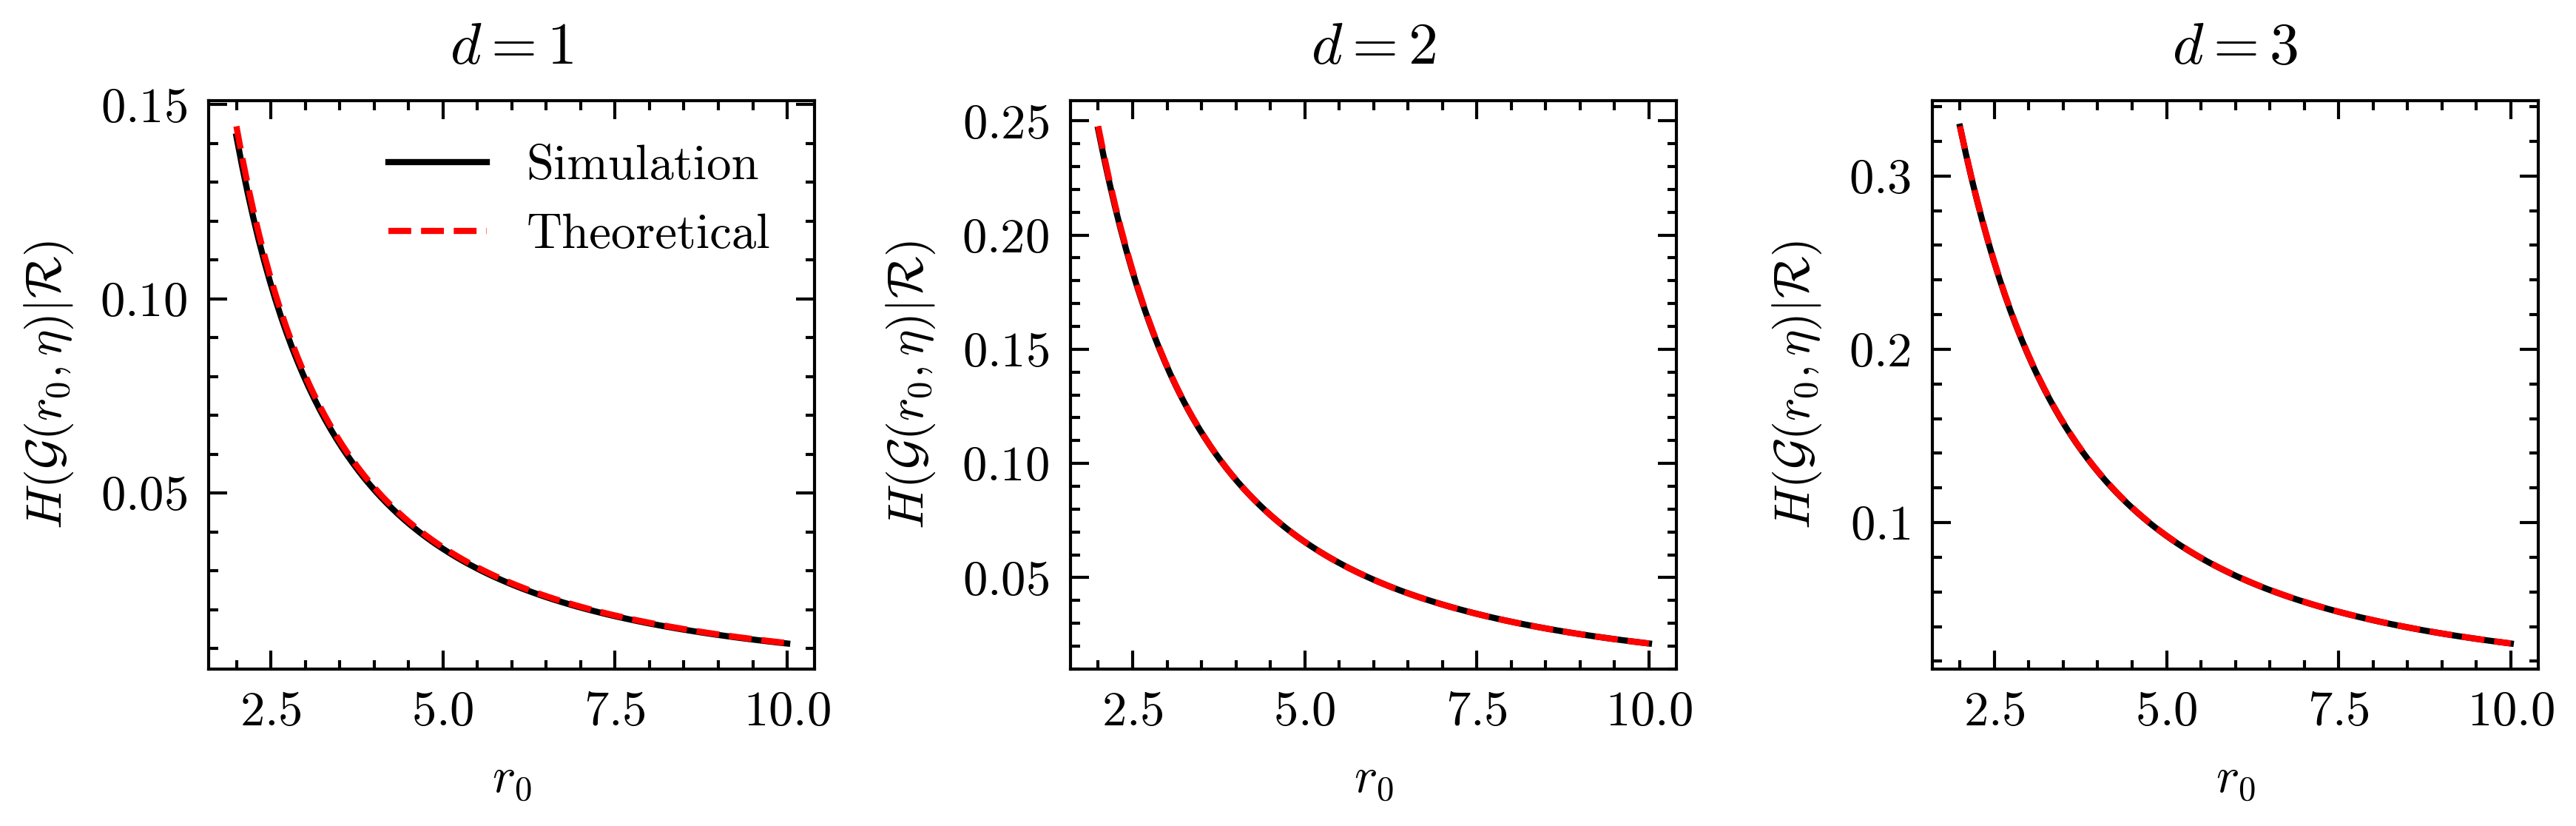

In [141]:
fig, ax = plt.subplots(1, 3, figsize=(6, 2))
r0s = np.linspace(2,10,100)

entropies = {}
for d in [1,2,3]:
    if d == 1:
        a0 = 2
    if d == 2:
        a0 = 2*np.pi
    if d == 3:
        a0 = 4*np.pi

    ent_vec = np.vectorize(lambda r0: H_bar_numerical(r0, eta, d))
    entropies[d] = ent_vec(r0s) 

    eta = 2

    ER = ERmoment(d, eta)
    ERlogR = ERlogRmoment(d, eta)
    ER2 = ERmoment2(d, eta)
    ER2logR = ERlogRmoment2(d, eta)
    approx = 1/(r0s**eta) * (1+eta*np.log(r0s)) * ER - eta/(r0s**eta) * ERlogR  - 1/2*1/(r0s**4) * (1+2*np.log(r0s)) * ER2# + 1/(r0s**4) * ER2logR

    ax[d-1].plot(r0s, entropies[d], label='Simulation')
    ax[d-1].plot(r0s, approx, label='Theoretical', linestyle='--')
    ax[d-1].set_title(r'$d=$'+str(d))
    ax[d-1].set_xlabel(r"$r_0$")
    ax[d-1].set_ylabel(r"$H(\mathcal{G}(r_0, \eta)|\mathcal{R})$")
    #ax[d-1].set_xticks([2,4,6,8,10])

ax[0].legend()
plt.tight_layout()
plt.show()


In [134]:
def f_disc(r, R):
    return 2*R**2*np.arccos(r/(2*R)) - r/2*np.sqrt(4*R**2 - r**2)


def disc_entropy(R, r0, eta=2):
    return quad(lambda r: f_disc(r, R)*h2(p(r, r0, eta)), 0, 2*R)[0]


disc_entropy_vec = np.vectorize(disc_entropy)


def f_sphere(r, R, eta=2):
    return 4/3*np.pi*R**3 * (1 - 3*r/(4*R) + r**3/(16*R**3)) if r <= 2*R else 0


def sphere_entropy(R, r0, eta=2):
    return quad(lambda r: f_sphere(r, R)*h2(p(r, r0, eta)), 0, 2*R)[0]

In [142]:
def ERmoment_d(eta, R):
    return quad(lambda r: r**eta * f_disc(r, R), 0, 2*R)[0]


def ER_moment_s(eta, R):
    return quad(lambda r: r**eta * f_sphere(r, R), 0, 2*R)[0]


def ERmoment2_d(eta, r):
    tot = 0
    for _ in range(10000):
        rs = np.sqrt(np.random.uniform(0, r, 2))
        thetas = np.random.uniform(0, 2*np.pi, 2)
        x1, y1 = rs[0] * np.cos(thetas[0]), rs[0] * np.sin(thetas[0])
        x2, y2 = rs[1] * np.cos(thetas[1]), rs[1] * np.sin(thetas[1])
        tot += np.sqrt((x1 - x2)**2 + (y1 - y2)**2)**(2*eta)
    return tot / 10000


def ERlogRmoment_d(eta, R):
    return quad(lambda r: np.log(r) * r**eta * f_disc(r, R), 0, 2*R)[0]


def ERlogRmoment_s(eta, R):
    return quad(lambda r: np.log(r) * r**eta * f_sphere(r, R), 0, 2*R)[0]


def ERlogRmoment2_d(eta, R):
    tot = 0
    for _ in range(10000):
        rs = np.sqrt(np.random.uniform(0, R, 2))
        thetas = np.random.uniform(0, 2*np.pi, 2)
        x1, y1 = rs[0] * np.cos(thetas[0]), rs[0] * np.sin(thetas[0])
        x2, y2 = rs[1] * np.cos(thetas[1]), rs[1] * np.sin(thetas[1])
        R_dist = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
        tot += np.log(R_dist) * R_dist**(2*eta)
    return tot / 10000

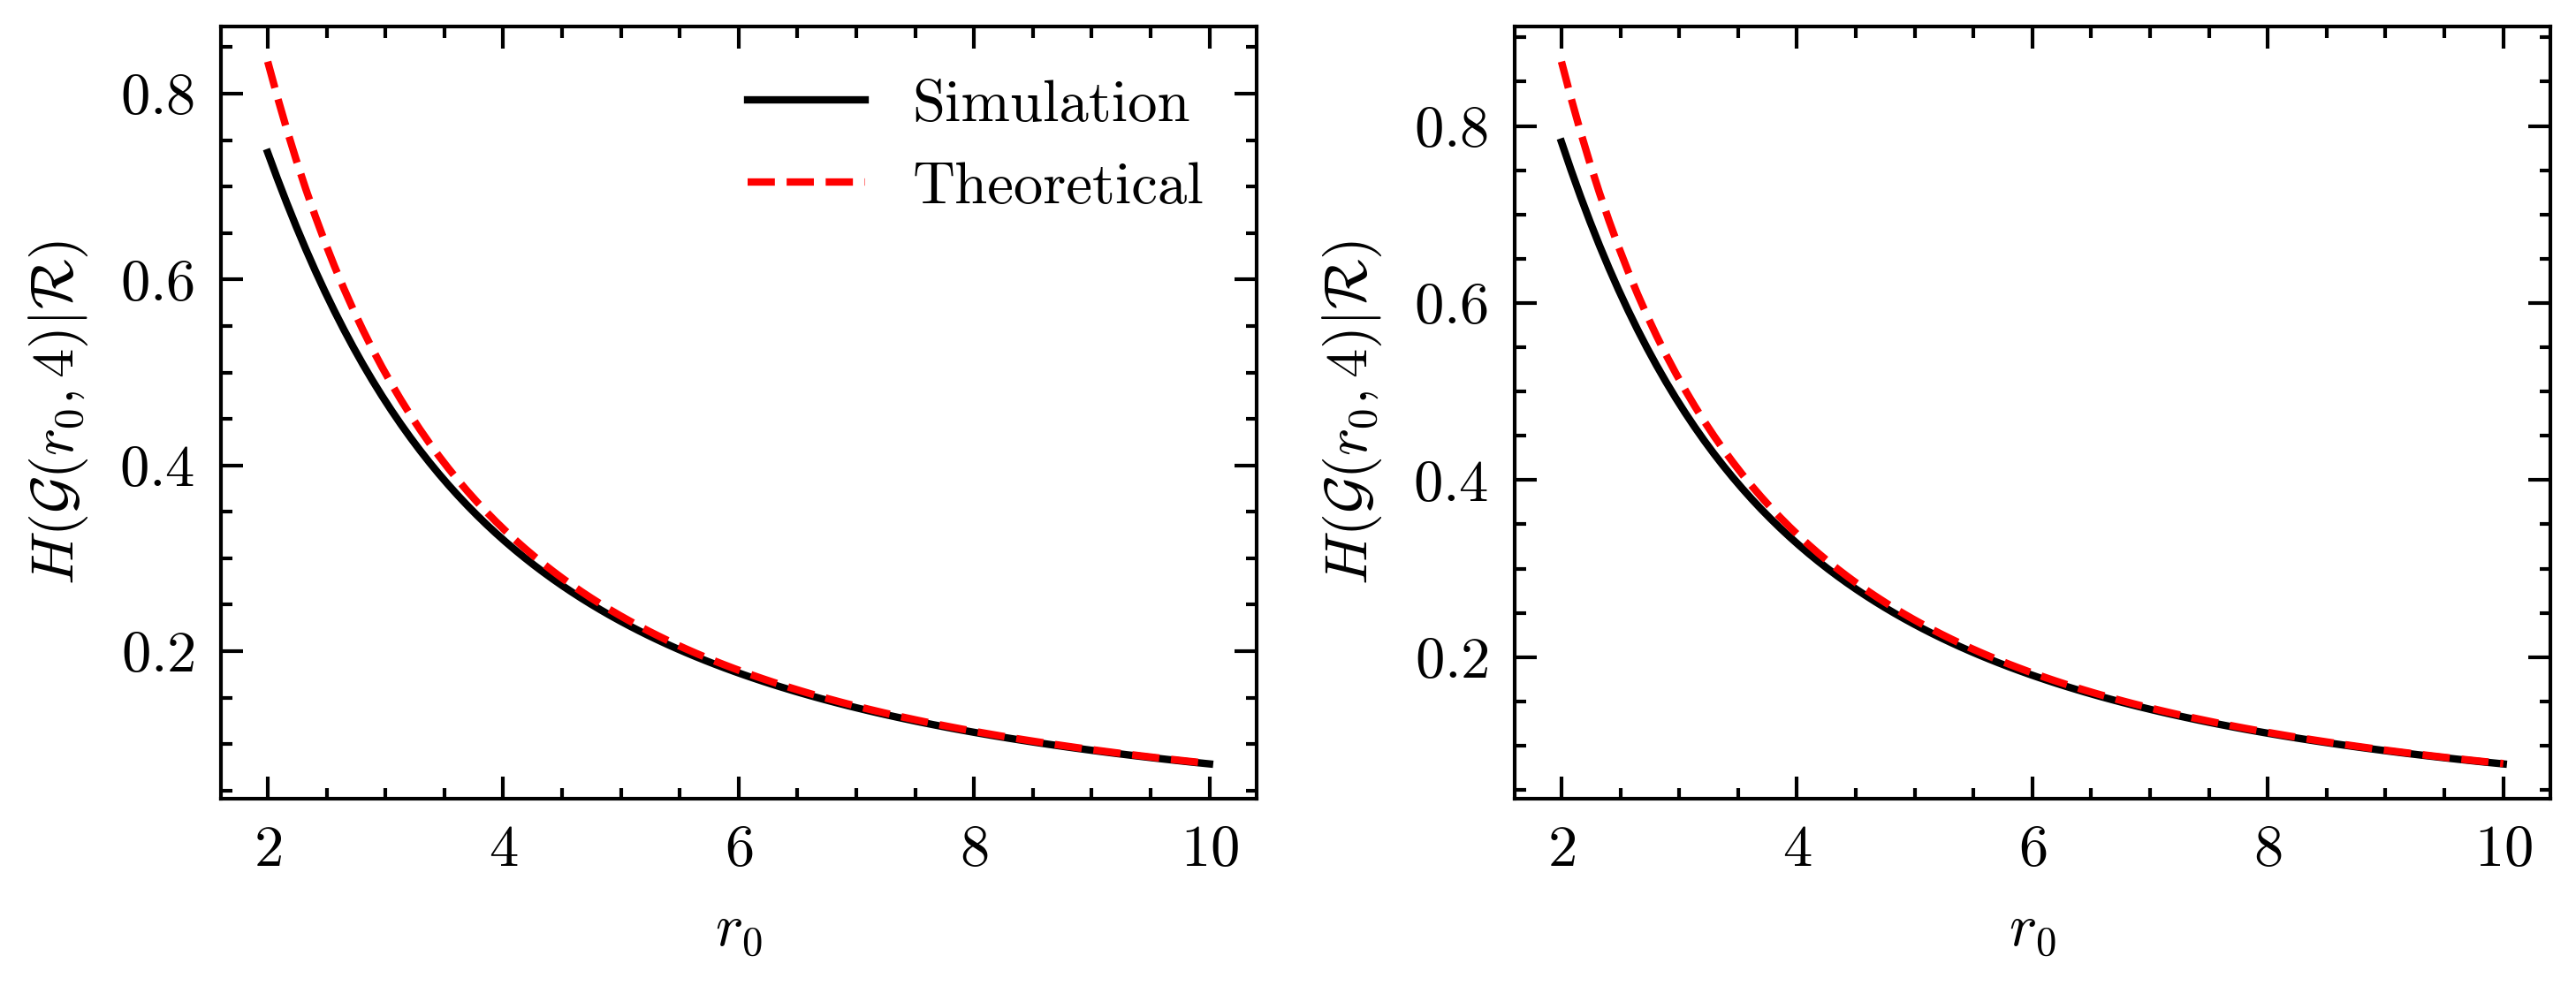

In [143]:
fig, ax = plt.subplots(1,2,figsize=(5,2))

R = 1
r0s_disc = np.linspace(2, 10, 100)
disc_entropy_array = np.array([disc_entropy_vec(R, r0, eta) for r0 in r0s_disc])
sphere_entropy_array = np.array([sphere_entropy(R, r0, eta) for r0 in r0s_disc])

# calculate the theory
H_approx = np.array([(1+eta*np.log(r0))/(r0**eta) * ERmoment_d(eta, R) - eta/(r0**eta) * ERlogRmoment_d(eta, R) for r0 in r0s_disc])
H_approx_sphere = np.array([(1+eta*np.log(r0))/(r0**eta) * ER_moment_s(eta, R) - eta/(r0**eta) * ERlogRmoment_s(eta, R) for r0 in r0s_disc])

ax[0].plot(r0s_disc, disc_entropy_array, label='Simulation')
ax[0].plot(r0s_disc, H_approx, label='Theoretical', linestyle='--')
ax[0].legend()
#ax[0].set_ylim(0,0.35)
ax[0].set_xlabel(r"$r_0$")
ax[0].set_ylabel(r"$H(\mathcal{G}(r_0, 4)|\mathcal{R})$")

ax[1].plot(r0s_disc, sphere_entropy_array, label='Sphere Simulation')
ax[1].plot(r0s_disc, H_approx_sphere, label='Sphere Theoretical', linestyle='--')
#ax[1].set_ylim(0,0.35)
ax[1].set_xlabel(r"$r_0$")
ax[1].set_ylabel(r"$H(\mathcal{G}(r_0, 4)|\mathcal{R})$")

plt.tight_layout()
plt.show()